In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data.csv')
df.head()

,webtoon_id,title,genre,thumbnail,summary,episodes,Created by,view,subscribe,grade,released_date,url,cover,likes,Written by,Art by,Adapted by,Original work by,Assisted by
0,1218,Let's Play,Romance,https://webtoon-phinf.pstatic.net/20210629_103...,"She’s young, single and about to achieve her d...",171,Leeanne M. Krecic (Mongie),606.5M,4.6M,9.59,"Nov 6, 2017",https://www.webtoons.com/en/romance/letsplay/l...,https://webtoon-phinf.pstatic.net/20210629_163...,37.2M,NaN,NaN,NaN,NaN,NaN
1,1436,True Beauty,Romance,https://webtoon-phinf.pstatic.net/20210129_175...,"After binge-watching beauty videos online, a s...",197,Yaongyi,874M,7M,9.53,"Aug 15, 2018",https://www.webtoons.com/en/romance/truebeauty...,https://webtoon-phinf.pstatic.net/20210129_65/...,46.2M,NaN,NaN,NaN,NaN,NaN
2,2135,The Remarried Empress,Fantasy,https://webtoon-phinf.pstatic.net/20200904_29/...,Navier Ellie Trovi was an empress perfect in e...,110,NaN,231.3M,2.5M,9.87,"Sep 5, 2020",https://www.webtoons.com/en/fantasy/the-remarr...,https://webtoon-phinf.pstatic.net/20200904_268...,21.2M,Alphatart,Sumpul,HereLee,NaN,NaN
3,1798,Midnight Poppy Land,Romance,https://webtoon-phinf.pstatic.net/20191119_132...,After making a grisly discovery in the country...,99,Lilydusk,198.8M,2.3M,9.80,"Nov 22, 2019",https://www.webtoons.com/en/romance/midnight-p...,https://webtoon-phinf.pstatic.net/20191119_163...,13.5M,NaN,NaN,NaN,NaN,NaN
4,3416,Reunion,Romance,https://webtoon-phinf.pstatic.net/20220311_196...,"After moving away for a decade, Rhea returns t...",9,stephattyy,7.1M,"629,872",9.77,"Mar 17, 2022",https://www.webtoons.com/en/romance/reunion/li...,https://webtoon-phinf.pstatic.net/20220311_14/...,"570,151",NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   webtoon_id        734 non-null    int64  
 1   title             734 non-null    object 
 2   genre             734 non-null    object 
 3   thumbnail         734 non-null    object 
 4   summary           734 non-null    object 
 5   episodes          734 non-null    int64  
 6   Created by        521 non-null    object 
 7   view              734 non-null    object 
 8   subscribe         734 non-null    object 
 9   grade             734 non-null    float64
 10  released_date     734 non-null    object 
 11  url               734 non-null    object 
 12  cover             734 non-null    object 
 13  likes             734 non-null    object 
 14  Written by        174 non-null    object 
 15  Art by            226 non-null    object 
 16  Adapted by        35 non-null     object 
 1

In [ ]:
print(df.columns.tolist())

['webtoon_id', 'title', 'genre', 'thumbnail', 'summary', 'episodes', 'Created by', 'view', 'subscribe', 'grade', 'released_date', 'url', 'cover', 'likes', 'Written by', 'Art by', 'Adapted by', 'Original work by', 'Assisted by']


In [4]:
df.isnull().sum()

,0
webtoon_id,0
title,0
genre,0
thumbnail,0
summary,0
episodes,0
Created by,213
view,0
subscribe,0
grade,0


In [ ]:
df.duplicated().sum()

np.int64(0)

Text Preprocessing

In [ ]:
import re

def bersihkan_teks(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

In [ ]:
df['text_features'] = df['genre'].astype(str) + " " + df['summary'].astype(str)

In [ ]:
df['text_clean'] = df['text_features'].apply(bersihkan_teks)

In [ ]:
df[['genre', 'summary', 'text_clean']].head()

,genre,summary,text_clean
0,Romance,"She’s young, single and about to achieve her d...",romance shes young single and about to achieve...
1,Romance,"After binge-watching beauty videos online, a s...",romance after bingewatching beauty videos onli...
2,Fantasy,Navier Ellie Trovi was an empress perfect in e...,fantasy navier ellie trovi was an empress perf...
3,Romance,After making a grisly discovery in the country...,romance after making a grisly discovery in the...
4,Romance,"After moving away for a decade, Rhea returns t...",romance after moving away for a decade rhea re...


TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['text_clean'])
print("Ukuran Matriks TF-IDF:", tfidf_matrix.shape)

Ukuran Matriks TF-IDF: (734, 7200)


Cosine Similarity

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Ukuran Matriks Cosine Similarity:", cosine_sim.shape)

Ukuran Matriks Cosine Similarity: (734, 734)


Fungsi Rekomendasi

In [ ]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

def get_recommendations(title, cosine_sim=cosine_sim, top_n=5):
    matches = df[df['title'].str.lower() == title.lower()]
    if matches.empty:
        return "Judul tidak ditemukan! Cek kembali ejaan kamu."

    # Ambil indeks dari judul yang cocok
    idx = matches.index[0]

    # Proses Cosine Similarity
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]

    webtoon_indices = [i[0] for i in sim_scores]

    result = df.iloc[webtoon_indices][['title', 'genre']].copy()
    result['similarity_score'] = [round(i[1], 3) for i in sim_scores]

    return result

In [ ]:
get_recommendations("Omniscient reader", top_n=5)

,title,genre,similarity_score
623,Surviving Romance,Horror,0.200
346,"Good Luck, Hero!",Fantasy,0.186
260,The Druid of Seoul Station,Action,0.160
679,Uriah,Horror,0.159
659,The Fever King,Superhero,0.154


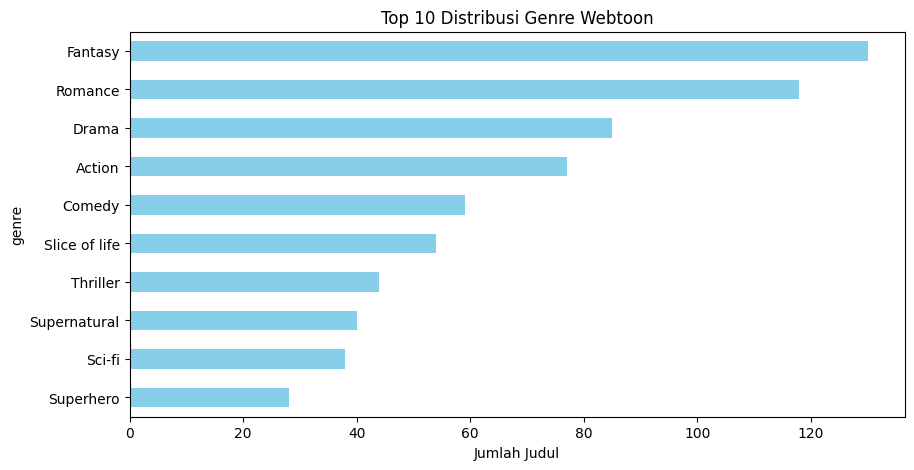

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
df['genre'].value_counts().head(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Distribusi Genre Webtoon')
plt.xlabel('Jumlah Judul')
plt.gca().invert_yaxis()
plt.show()

insight : Katalog Webtoon didominasi oleh genre Fantasy, Action, dan Romance.

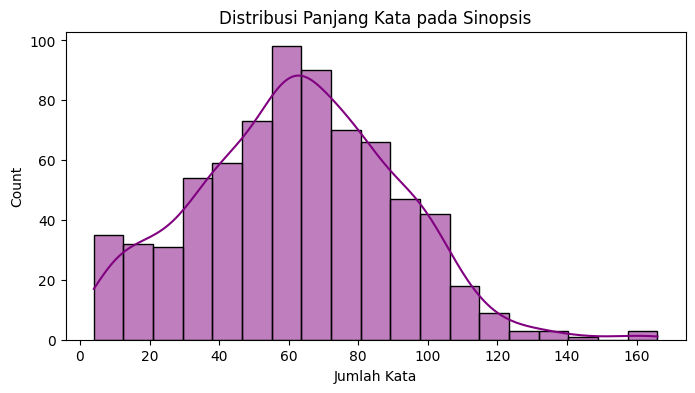

In [6]:
df['summary_word_count'] = df['summary'].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(8, 4))
sns.histplot(df['summary_word_count'], kde=True, color='purple')
plt.title('Distribusi Panjang Kata pada Sinopsis')
plt.xlabel('Jumlah Kata')
plt.show()

insight : Mayoritas sinopsis tergolong pendek, dengan rata-rata 30–60 kata per komik.